# Introduction

LLMs are powerful, but when building real applications they hit three fundamental walls:

- **Knowledge Gap: LLMs** have a fixed training cutoff. Your SQL agent can't know about a model validation finding submitted yesterday, or a regulatory update published last week.
- **Capability Gap**: LLMs struggle with precise calculations. Ask one to compute a risk-weighted capital figure or aggregate across hundreds of model findings — it may hallucinate numbers rather than compute them correctly.
- **Action Gap**: LLMs can only generate text. They can't actually update a finding's status, assign it to a reviewer, or trigger a remediation workflow.

These three gaps are what prevent LLMs from handling many real-world tasks on their own. Does this framing make sense so far?

`yes`

**Tools** are the solution — external functions or services that LLMs can call whenever they determine it's useful for the task at hand. Critically, the **model itself decides** when to use them based on the conversation context.

There are three categories, each addressing one of those gaps. Let's start with the first.

**Information Retrieval Tools** tackle the knowledge gap by pulling in external data on demand. For your SQL agent, this is already familiar territory — querying live model risk data is a form of information retrieval. But it extends further:

- **Web search** for current regulatory guidance or industry news
- **API calls** for real-time risk metrics or market data
- **SQL queries** against your model inventory database
- **Document search** across validation reports or audit findings

As you can see here, this directly addresses that first limitation — bringing relevant, current information into the LLM's context for each query.

Does this first category make sense?

`yes`

The two key differences are scope and control:

**Scope**: RAG only addresses the knowledge gap. Tools address all three gaps — knowledge, capabilities, and actions.

**Control**: Look at the RAG diagram here — every user query automatically triggers retrieval. It assumes every input is a question answerable by your knowledge base. Tools flip this: the **LLM decides** whether retrieval is even needed, which source to query, and what to fetch — based on the full conversation context. This is what we call **dynamic retrieval vs RAG's automatic retrieval**.

So for your SQL agent: if you built it with RAG, it would query the database on every single message. With tools, it only queries when the user actually needs data — and it can also do calculations or trigger actions in the same conversation.

**When to choose**:

**RAG** → every user input is a question answerable by retrieving similar content
**Tools** → you need the LLM to decide whether, when, and where to retrieve

Clear on the distinction?

`yes`

Now the second category: **Capability Extension Tools** address the capability gap — tasks the LLM simply can't do reliably.

Think about your model risk work: calculating a **risk-weighted capital figure**, aggregating severity scores across hundreds of findings, or running a statistical analysis on validation outcomes. These require precise computation — something LLMs notoriously struggle with.

Capability extension tools are essentially **Python functions** that perform these operations reliably and return the result to the LLM. They can cover anything: mathematical computations, statistical analysis, data transformations, code execution — if it can be written in Python, it can be a tool.

As you can see here, this directly plugs the capability gap alongside the knowledge gap we just covered.

Thinking about your SQL agent or model risk applications — are there specific capabilities you think would be most valuable to extend with tools?

`looking up relevant policy or regulatory requirements`

That's a great example — and it actually sits at the boundary of information retrieval and capability extension. Looking up a specific policy document is retrieval, but **interpreting whether a finding maps to a regulatory requirement** could involve structured matching logic you'd encode as a tool.

Other high-value capabilities for model risk work might include:

**Risk scoring calculations** — computing composite severity scores from multiple finding attributes
**Deadline tracking** — calculating days remaining to remediation based on finding dates and SLA rules
**Compliance gap analysis** — systematically checking findings against a policy checklist

All of these are things LLMs would either hallucinate or get wrong — but a Python function nails them every time.

Does this category make sense before we move to the third?

`yes`

The third category: **Action Execution Tools** close the action gap — letting the LLM actually do things in external systems.

For model risk, this is where things get powerful. Instead of just surfacing a finding, your assistant could:

- **Update a finding's status** in your risk database
- **Assign remediation** to the responsible model owner
- **Send notifications** to reviewers when a deadline is approaching
- **Trigger a review workflow** when a new regulatory requirement is flagged

As you can see here, all three gaps now have a solution — and together they transform an LLM from a text generator into an active participant in your workflows.

By the way — you'll see this capability referred to by different names depending on the context: **"function calling", "tool calling", or "taking actions"**. They all mean the same thing. LangChain uses "tool use", which is what we'll stick with throughout this course.

Here's the full picture of what happens:

1. **Tool Guidance**: We include tool descriptions in the system prompt — name, arguments, expected output, and when to use each tool. This is how the LLM "knows" about them.
2. **Tool Selection**: The LLM analyzes the user input and the full conversation context, then decides whether and which tool to use.
3. **Tool Call**: The LLM returns a structured message specifying the tool name and the argument values — it doesn't execute anything itself.
4. **Execution**: Our system receives that structured call, executes the actual function, and captures the result.
5. **Response Generation**: The result is sent back to the LLM, which incorporates it into a final response.

The key insight you nailed: the LLM never runs code directly — it just specifies what to call and with what arguments, and our application handles execution.

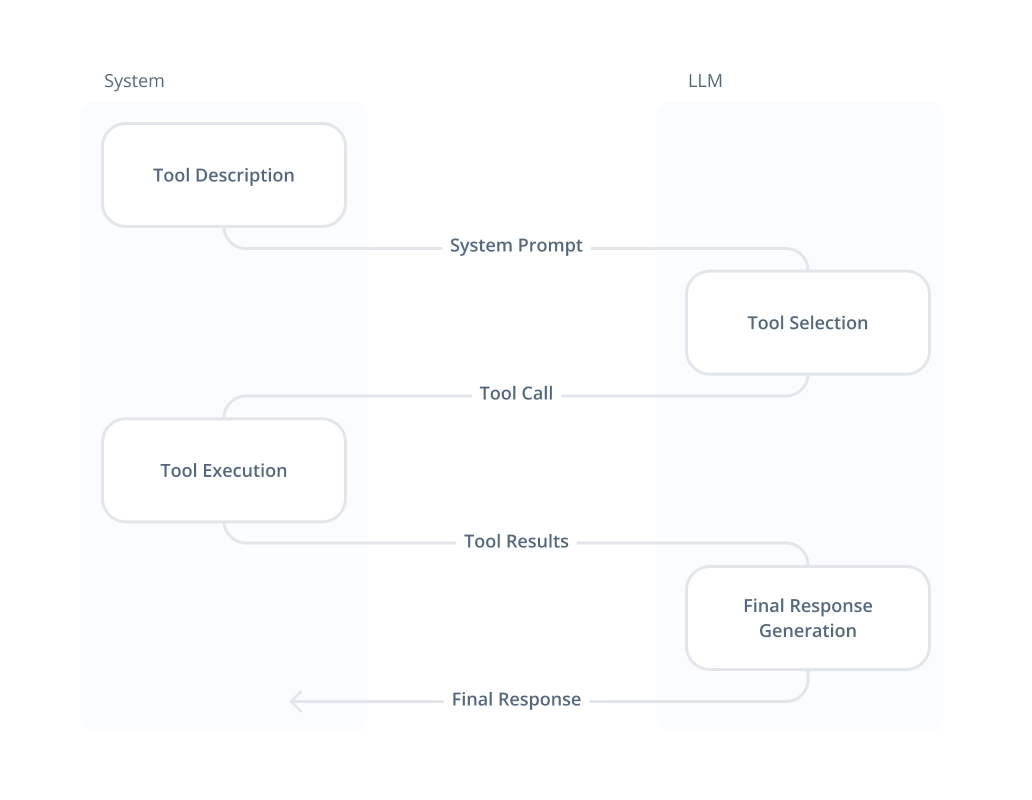

Does this flow make sense?

`yes`

Now let's see how that operation maps to the actual messages exchanged. You're already familiar with System, Human, and AI messages — tool use just adds some structure on top.

Here's the full message flow for a single tool call:

- **System Message**: The prompt — including tool descriptions
- **Human Message**: The user's input
- **AI Message**: The LLM's response, which may contain a tool call request
- **Tool Message**: Our system's reply containing the tool execution result
- **AI Message**: The final response incorporating the tool output

The AI message is the same one you already know — we're just getting to know that it has an additional tool_calls field alongside content. Does this sequence make sense so far?

`yes`

Let's zoom into the **AI Message structure**- here. It has two fields:

- content: The text response — this will be empty when the LLM is making a tool call
- tool_calls: An array of tool call objects, each with the format: {"id": "unique_id", "name": "tool_name", "args": {argument_dict}}

The id is important — it's how the system tracks which tool call a result belongs to, especially when multiple tools are called at once.

Now let me introduce the **Tool Message** — a new message type you haven't seen before.

The **Tool Message** is what our system sends back after executing a tool call. It has three fields:

- tool_call_id: Matches the id from the AI message's tool call — this links the result back to the request
- name: The tool name for reference
- content: The actual execution result

Now, you've seen all four message types across this course. Can you give a brief description of each — System, Human, AI, and Tool messages?

To summarize all four:

- **System Message**: Defines the LLM's role, behavior, and guardrails — including tool descriptions
- **Human Message**: The user's input
- **AI Message**: The LLM's response — contains content for text and tool_calls when requesting tool execution
- **Tool Message**: Our system's reply after executing a tool — contains the result linked back via tool_call_id
  
That's the complete message vocabulary for tool-augmented applications. Clear on all four?

Exactly right. Here's the full picture — with tools, total response time becomes tc + te + tg instead of just tg:

- **tc** (tool call generation): Time for the LLM to decide to use a tool and generate the structured call
- **te** (tool execution): Time to run your function and return the result — this is exactly what you said: depends entirely on what the tool does. A Python calculation is near-instant; a database query or web search can take seconds.
- **tg** (response generation): The final LLM response — same as always

A few practical guidelines:

- **Justify every tool call** — if the LLM can answer well enough directly, skip the tool
- **Design your UX for the wait** — progress indicators, staged loading
- **Offload non-blocking operations** to background processes where possible
For your SQL agent, query latency is likely the dominant factor — something worth optimizing as you move toward production.

Any questions about latency before we move on?

## Case study

To make things concrete, we'll build a real application throughout this lesson — a **travel booking assistant**.

Imagine a hotel booking platform where users are stuck navigating forms and structured interfaces. They start asking things like:

- "How much would **5 nights cost with taxes**?"
- "Will the **weather be good** for the beach?"
- "Can you **book that second** hotel for me?"
- "Will that be around the time of the **Marathon**?"
- "I leave New York at 10am, **what time will it be in Tokyo when I arrive?**"

The platform can't handle any of these today. We'll evolve it into a comprehensive travel assistant that handles the entire booking journey in one conversation — search, cost calculation, web search, weather, bookings, and timezone handling.

Given these user needs, what capabilities would you add to handle them?


Good thinking! Here's the full set of capabilities we'll build:

- Hotel Search → queries our hotel database by city and dates (information retrieval)
- Cost Calculator → computes total stay cost including taxes (capability extension — precise math)
- Web Search → finds current events, attractions, and local information (information retrieval)
- Weather Info → retrieves weather forecasts for destinations (information retrieval — your weather tool!)
- Room Booking → completes reservations directly through the conversation (action execution)
- Time Context → handles timezone conversions and date calculations (capability extension)

You nailed weather and web search. The distance tool is an interesting idea — not in our scope here, but it would fit naturally as a capability extension tool.

Notice how each tool maps to one of the three LLM limitations we covered. Does this make sense?

We'll build this assistant across three lessons, adding one layer of capability at a time:

- **Lesson 1** — Tool Fundamentals (this lesson): Hotel search, cost calculator, and web search. You'll learn the core concepts and how to build custom tools or use LangChain-provided tools.
- **Lesson 2** — API Tools: Weather and booking tools. You'll learn how to wrap external APIs as tools.
- **Lesson 3** — Managed Tools: Enhanced web search and time tools. You'll learn to use LLM provider tools and connect to MCP tool servers maintained by others.

Don't worry if Lesson 3 sounds abstract right now — everything will click as we build up to it. By the end, you'll have a solid grasp of the full range of tool types you can bring into any LLM application.

Here's how we'll work through each capability: design first, then implement, then test — so you see the full end-to-end flow each time before moving to the next tool.

We'll add one tool at a time, keeping things focused and building confidence as the assistant grows.

Ready to start building? 

`I thought you never asked`

Let's start with the **Hotel Search tool**. Our platform already has a search function that takes a city and dates, and returns matching hotels. We don't need to rebuild that logic — we just need to **wrap it as a tool** so the LLM can call it when a user asks about hotels, but only then, not on every message.

This is a key design principle: **expose existing functionality** rather than rewrite it. The tool becomes a thin wrapper that makes your existing code accessible to the LLM.

Does this approach make sense before we implement it?

Here it is — the existing search_hotels_db function is in lines 14–32. It calls our hotel booking API with city and dates, then formats the results into a readable list.

The new code starts at line 38 — the query_hotels tool that wraps it. But let's not get ahead of ourselves.

First, take a look at the function body and then run the code to confirm it works as expected — there's a test call at the bottom that searches for hotels in Tokyo next week.

In [15]:
from datetime import datetime, timedelta
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, SystemMessage
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from dotenv import load_dotenv
from devtools import pprint
import requests

load_dotenv()

HOTEL_API_URL = "https://hotel-booking-server-1085074390115.us-east4.run.app"


def search_hotels_db(city: str, check_in: str, check_out: str) -> str:
    """Call the hotel booking API to search for available hotels."""
    response = requests.get(
        f"{HOTEL_API_URL}/hotels/search",
        params={"city": city, "check_in": check_in, "check_out": check_out},
    )
    hotels = response.json()

    if not hotels:
        return "No hotels found matching your criteria."

    formatted = []
    for i, hotel in enumerate(hotels, 1):
        formatted.append(
            f"{i}. {hotel['name']} in {hotel['city']}"
            f" - ${hotel['price_per_night']}/night"
            f" - {hotel['rating']} stars"
        )
    return "\n".join(formatted)


# -----NEW CODE-----#


@tool
def query_hotels(city: str, check_in: str, check_out: str) -> str:
    """Search for available hotels in a city for given dates.

    Args:
        city: City name to search hotels in
        check_in: Check-in date (YYYY-MM-DD)
        check_out: Check-out date (YYYY-MM-DD)

    Returns:
        List of available hotels with pricing
    """
    return search_hotels_db(city, check_in, check_out)


next_week = (datetime.now() + timedelta(days=7)).strftime("%Y-%m-%d")
print(next_week)
next_week_plus_one = (datetime.now() + timedelta(days=8)).strftime("%Y-%m-%d")
print(next_week_plus_one)
print(
    query_hotels.invoke(
        {"city": "Tokyo", "check_in": next_week, "check_out": next_week_plus_one}
    )
)



2026-06-24
2026-06-25
1. Tokyo Grand Hotel in Tokyo - $150.0/night - 4.0 stars
2. Sakura Onsen Resort in Tokyo - $180.0/night - 4.0 stars
3. Tokyo Business Hotel in Tokyo - $120.0/night - 4.0 stars
4. Imperial Palace Hotel in Tokyo - $250.0/night - 4.0 stars
5. Zen Garden Hotel in Tokyo - $200.0/night - 4.0 stars


The search works — five Tokyo hotels returned with pricing and ratings. The LangSmith warning is harmless, just a tracing permission issue in this environment.

Now let's look at what turns this into a tool. Notice lines 38–50 — the query_hotels function decorated with @tool that wraps search_hotels_db.

Are you familiar with Python decorators and docstrings?

`No, let's go through it`

No problem! Let's break it down.

**Decorators** (the `@tool` on line 38) are Python's way of wrapping a function to add extra behavior. Writing `@tool` above a function is equivalent to calling `query_hotels = tool(query_hotels)` — LangChain's `tool()` function takes your function and transforms it into a LangChain tool object with all the machinery needed for LLM integration.

**Docstrings** (lines 40–48) are the triple-quoted string right after the function definition. They describe what the function does, its arguments, and its return value.

Now here's why both matter critically for tool use: when `@tool` is applied, LangChain reads **the docstring and type hints** to automatically generate a tool schema — a structured description the LLM uses to understand:

- What the tool does ("Search for available hotels..." → tool description)
- What arguments it needs (city, check_in, check_out → parameter names and types)
- What it returns

This schema is what gets sent to the LLM in the system prompt. **The quality of your docstring directly affects how well the LLM uses the tool** — a vague docstring means poor tool selection.

Does this make sense?

`yes`

Now let's connect this to tool schema extraction. When LangChain processes @tool, it automatically builds a schema from three things you can see here:

- **Line 38**: `@tool` — triggers the transformation
- **Line 39**: **query_hotels(city: str, check_in: str, check_out: str) -> str** — type hints define parameter types and whether they're required
- **Lines 40–48**: The docstring becomes the tool description and argument descriptions the LLM reads

This schema is what gets passed to the LLM in the prompt so it knows when and how to call the tool. You never write the schema manually — LangChain extracts it for you.

All clear on the schema extraction before we move to binding the tool to the LLM?

Now let's wire the tool into our `TravelAssistant` and see the full flow in action. Here's the complete assistant — let's start with the **high-level structure**.

The class has two parts: __init__ sets everything up, and chat handles each user message. Within __init__, three things are initialized: the **LLM**, the **tools dictionary**, and the **message history** with a system prompt.

Does this high-level structure make sense before we dig into the details?

In [19]:
class TravelAssistant:
    def __init__(self):
        self.llm = init_chat_model("gpt-4o-mini", model_provider="openai")
        self.tools = {"query_hotels": query_hotels}
        self.llm_with_tools = self.llm.bind_tools(self.tools.values())
        self.messages = []

        current_year = datetime.now().year

        # System prompt
        self.system_prompt = f"""You are a helpful travel assistant that 
        can search for hotels and help with trip planning. When users 
        ask about hotels, use the query_hotels tool to search our database. Be conversational and helpful in your responses.
        Your current year is {current_year}."""

        self.messages.append(SystemMessage(content=self.system_prompt))

    def chat(self, message: str):
        # Add user message
        self.messages.append(HumanMessage(content=message))

        # Get AI response with potential tool calls
        response = self.llm_with_tools.invoke(self.messages)
        print(response.tool_calls)
        self.messages.append(response)

        # Check if tools were called
        if response.tool_calls:
            # Execute each tool call
            for tool_call in response.tool_calls:
                tool = self.tools[tool_call["name"]]
                tool_result = tool.invoke(tool_call)
                self.messages.append(tool_result)

            # Get final response after tool execution
            final_response = self.llm_with_tools.invoke(self.messages)
            self.messages.append(final_response)


# Test single tool call
assistant = TravelAssistant()
next_week = (datetime.now() + timedelta(days=7)).strftime("%Y-%m-%d")
assistant.chat(f"Find me a hotel in Tokyo for one night on {next_week}")
for msg in assistant.messages:
    msg.pretty_print()



[{'name': 'query_hotels', 'args': {'city': 'Tokyo', 'check_in': '2026-06-24', 'check_out': '2026-06-25'}, 'id': 'call_XrjGnOAiO1wDsNUBq3HWj4v8', 'type': 'tool_call'}]
================================ System Message ================================

You are a helpful travel assistant that 
        can search for hotels and help with trip planning. When users 
        ask about hotels, use the query_hotels tool to search our database. Be conversational and helpful in your responses.
        Your current year is 2026.
================================ Human Message =================================

Find me a hotel in Tokyo for one night on 2026-06-24
================================== Ai Message ==================================
Tool Calls:
  query_hotels (call_XrjGnOAiO1wDsNUBq3HWj4v8)
 Call ID: call_XrjGnOAiO1wDsNUBq3HWj4v8
  Args:
    city: Tokyo
    check_in: 2026-06-24
    check_out: 2026-06-25
================================= Tool Message =================================
Name: qu

In [10]:
{"a": 1}.values()

dict_values([1])

`I though tools needs to be a list` 

Good catch — bind_tools does accept a list, and .values() on a dictionary returns a dict_values object that behaves like a list. So it works either way.

Using a dictionary for self.tools (line 56) is a deliberate design choice: it lets you look up tools by name efficiently on line 82 — self.tools[tool_call["name"]]. If you stored them as a list, you'd have to loop through to find the right tool by name each time.

Then line 57 — bind_tools creates a new version of the LLM that has the tool schemas attached. From this point on, whenever you invoke self.llm_with_tools, the LLM knows what tools are available and can decide to call them.

Does this make sense?

`yes`

What do you think happens if the LLM decides not to use any tools?

`then the messages list last element is the response of the first llm call`

Exactly right — if response.tool_calls is empty, the if block is skipped entirely and the function returns. The last message in the history is already the AI's direct response, which is the final answer.

When tools are called, lines 87–88 handle the follow-up: after all tool results are appended, the LLM is invoked again with the full updated history — now including the tool messages — to generate the final response.

So the flow reduces to:

- No tools needed → one LLM call, done
- Tools needed → LLM call → tool execution → second LLM call with results

Let's walk through the output.

The message sequence shows exactly the flow we designed:

1. **System Message** — the assistant prompt with tool guidance
2. **Human Message** — your Tokyo hotel query
3. **AI Message** — empty content, with a tool_calls entry: query_hotels called with city: Tokyo, check_in: 2026-06-24, check_out: 2026-06-25. The LLM decided on its own to use the tool and extracted the right arguments from the natural language query.
4. **Tool Message** — the hotel list returned by our function, linked via the matching call_id
5. **AI Message** — the final conversational response to the user

The key insight here: **the LLM never executed any code** — it just specified what to call and with what arguments. Our loop handled execution and fed the result back.

That's the complete single tool call flow. Clear on how everything connects?


#### add cost calculator tool

Now let's add the **Cost Calculator tool**. Our assistant can find hotels — but users want to know the total cost including taxes before committing.

LLMs notoriously struggle with precise arithmetic, so we'll create a simple Python function that takes price per night, number of nights, and a tax rate, then computes a reliable cost breakdown. No external API needed — just a function the LLM can call instead of attempting the math itself.

This is capability extension in its purest form. Clear before we implement?

In [20]:
@tool
def calculate_total_cost(
    price_per_night: float, num_nights: int, tax_rate: float = 0.05
) -> str:
    """Calculate total hotel cost including taxes.

    Args:
        price_per_night: Hotel rate per night
        num_nights: Number of nights
        tax_rate: Tax rate (default 5%)

    Returns:
        Detailed cost breakdown
    """
    subtotal = price_per_night * num_nights
    tax = subtotal * tax_rate
    total = subtotal + tax

    return f"""Cost Breakdown:
- Rate: ${price_per_night:.2f} x {num_nights} nights = ${subtotal:.2f}
- Tax ({tax_rate * 100}%): ${tax:.2f}
- Total: ${total:.2f}"""


print(
    calculate_total_cost.invoke(
        {"price_per_night": 150.0, "num_nights": 3, "tax_rate": 0.07}
    )
)



Cost Breakdown:
- Rate: $150.00 x 3 nights = $450.00
- Tax (7.000000000000001%): $31.50
- Total: $481.50


Here's the **calculate_total_cost tool**. The pattern is identical to query_hotels — @tool decorator, descriptive docstring, type hints — but the function body is pure Python math rather than an API call.

Notice `tax_rate: float = 0.05` — a default argument, so the LLM can omit it if the user doesn't specify a tax rate.

The test call at the bottom invokes it directly. Go ahead and **run the code** to see the cost breakdown output.

The cost breakdown is correct — **$150 × 3 nights = $450**, plus 7% tax = **$481.50**. Reliable, precise, every time — exactly what you can't trust an LLM to compute on its own.

This is what **function tools** are all about: any Python function decorated with `@tool` becomes a capability the LLM can call. The function can use any Python library, perform any computation, and return a string result. Simple but powerful.

#### Code so far

This is the same code as before with two changes — we've added `calculate_total_cost` to the tools dictionary and updated the system prompt to guide when to use it.

Let me highlight those specific changes.

In [21]:
from datetime import datetime, timedelta
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, SystemMessage
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from dotenv import load_dotenv
from devtools import pprint
import requests

load_dotenv()

HOTEL_API_URL = "https://hotel-booking-server-1085074390115.us-east4.run.app"


def search_hotels_db(city: str, check_in: str, check_out: str) -> str:
    """Call the hotel booking API to search for available hotels."""
    response = requests.get(
        f"{HOTEL_API_URL}/hotels/search",
        params={"city": city, "check_in": check_in, "check_out": check_out},
    )
    hotels = response.json()

    if not hotels:
        return "No hotels found matching your criteria."

    formatted = []
    for i, hotel in enumerate(hotels, 1):
        formatted.append(
            f"{i}. {hotel['name']} in {hotel['city']}"
            f" - ${hotel['price_per_night']}/night"
            f" - {hotel['rating']} stars"
        )
    return "\n".join(formatted)


@tool
def query_hotels(city: str, check_in: str, check_out: str) -> str:
    """Search for available hotels in a city for given dates.

    Args:
        city: City name to search hotels in
        check_in: Check-in date (YYYY-MM-DD)
        check_out: Check-out date (YYYY-MM-DD)

    Returns:
        List of available hotels with pricing
    """
    return search_hotels_db(city, check_in, check_out)


# -----NEW CODE-----#


@tool
def calculate_total_cost(
    price_per_night: float, num_nights: int, tax_rate: float = 0.05
) -> str:
    """Calculate total hotel cost including taxes.

    Args:
        price_per_night: Hotel rate per night
        num_nights: Number of nights
        tax_rate: Tax rate (default 5%)

    Returns:
        Detailed cost breakdown
    """
    subtotal = price_per_night * num_nights
    tax = subtotal * tax_rate
    total = subtotal + tax

    return f"""Cost Breakdown:
- Rate: ${price_per_night:.2f} x {num_nights} nights = ${subtotal:.2f}
- Tax ({tax_rate * 100}%): ${tax:.2f}
- Total: ${total:.2f}"""


class TravelAssistant:
    def __init__(self):
        self.llm = init_chat_model("gpt-4o-mini", model_provider="openai")
        self.tools = {
            "query_hotels": query_hotels,
            "calculate_total_cost": calculate_total_cost,
        }
        self.llm_with_tools = self.llm.bind_tools(self.tools.values())
        self.messages = []

        current_year = datetime.now().year

        self.system_prompt = f"""You are a helpful travel assistant that 
        can search for hotels and calculate costs. When 
        users ask about hotels, use the query_hotels tool. When users 
        ask about total costs, use the calculate_total_cost tool. You can call it multiple times for different hotels. Be conversational and helpful in your responses.
        Your current year is {current_year}."""

        self.messages.append(SystemMessage(content=self.system_prompt))

    def chat(self, message: str):
        # Add user message
        self.messages.append(HumanMessage(content=message))

        # Get AI response with potential tool calls
        response = self.llm_with_tools.invoke(self.messages)
        self.messages.append(response)

        # Check if tools were called
        if response.tool_calls:
            # Execute each tool call
            for tool_call in response.tool_calls:
                tool = self.tools[tool_call["name"]]
                tool_result = tool.invoke(tool_call)
                self.messages.append(tool_result)

            # Get final response after tool execution
            final_response = self.llm_with_tools.invoke(self.messages)
            self.messages.append(final_response)


# Test parallel tool calls
assistant = TravelAssistant()
next_week = (datetime.now() + timedelta(days=7)).strftime("%Y-%m-%d")
assistant.chat(f"Find me a hotel in Tokyo for {next_week}")
assistant.chat(
    "What would be the total cost including taxes for 3 nights at the first two hotels?"
)
for msg in assistant.messages:
    msg.pretty_print()



================================ System Message ================================

You are a helpful travel assistant that 
        can search for hotels and calculate costs. When 
        users ask about hotels, use the query_hotels tool. When users 
        ask about total costs, use the calculate_total_cost tool. You can call it multiple times for different hotels. Be conversational and helpful in your responses.
        Your current year is 2026.
================================ Human Message =================================

Find me a hotel in Tokyo for 2026-06-24
================================== Ai Message ==================================
Tool Calls:
  query_hotels (call_9qagqHYWROz4f1KVQxkZjXeL)
 Call ID: call_9qagqHYWROz4f1KVQxkZjXeL
  Args:
    city: Tokyo
    check_in: 2026-06-24
    check_out: 2026-06-25
================================= Tool Message =================================
Name: query_hotels

1. Tokyo Grand Hotel in Tokyo - $150.0/night - 4.0 stars
2. Sakura O

Now let's talk about something new. So far, the LLM has only called **one tool at a time** — but it can actually call **multiple tools simultaneously** when their inputs are independent. That's why we have the loop on **lines 106–111** — it handles however many tool calls the LLM decides to make in one go.

The test example on lines 119–124 is designed to trigger exactly this: the second message asks for costs for two hotels, so the LLM should call `calculate_total_cost` twice in parallel — once per hotel.
